# Stage 03 — Profile and data quality (forecasting-focused)
Goal: know what could mislead a weekly demand model on SITE_NAME x ARTICLE.

In [1]:
import sys
sys.path.insert(0, "../../plugins/dslc/skills/dslc/scripts")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from dslc_style import apply_style, SERIES, INK, save
apply_style()
d = pd.read_csv("data/raw/perishable_45k.csv", low_memory=False, parse_dates=["BILL_DATE", "EXPIRY_DATE"])
print(d.shape, d.memory_usage(deep=True).sum() // 2**20, "MB", d.BILL_DATE.min(), d.BILL_DATE.max())

(45000, 41) 63 MB 2024-04-01 00:00:00 2025-03-31 00:00:00


## Data dictionary

In [2]:
dd = pd.DataFrame({"dtype": d.dtypes.astype(str), "pct_missing": (d.isna().mean() * 100).round(1),
                   "n_unique": d.nunique(), "example": [d[c].dropna().iloc[0] if d[c].notna().any() else None for c in d.columns]})
import os; os.makedirs("reports/tables", exist_ok=True)
dd.to_csv("reports/tables/data_dictionary.csv"); print(dd.to_string())

                            dtype  pct_missing  n_unique                           example
SITE                       object          2.8        10                        West-Fresh
SITE_NAME                  object          0.0         5                  West Fresh Store
BILL_DATE          datetime64[ns]          0.0       365               2024-11-06 00:00:00
BILL_TIME                  object          0.0     12919                          19:16:53
BILL_TYPE                  object          0.0         2                            Return
BILL_NO                    object          6.9     14777                  Wes/0012655-1124
CUSTOMER_NAME              object         16.1     12344                           Walk-in
MOBILE                    float64         20.4     12871                      9158672093.0
MOBILE_HASH                object         12.5     13130                  247cb9683ec108ba
SALES_CHANNEL              object          0.0         8                          In-Store

## Quality checks

In [3]:
q = {}
q["exact_duplicate_rows"] = int(d.duplicated().sum())
q["dup_bill_article"] = int(d.dropna(subset=["BILL_NO"]).duplicated(["BILL_NO", "ARTICLE"]).sum())
q["sale_qty0"] = int(((d.BILL_TYPE == "Sale") & (d.BILL_QUANTITY == 0)).sum())
q["return_rows"] = int((d.BILL_TYPE == "Return").sum())
q["return_positive_net"] = int(((d.BILL_TYPE == "Return") & (d.NET_AMOUNT > 0)).sum())
q["sale_negative_net"] = int(((d.BILL_TYPE == "Sale") & (d.NET_AMOUNT < 0)).sum())
q["expiry_before_bill"] = int((d.EXPIRY_DATE < d.BILL_DATE).sum())
q["article_missing"] = int(d.ARTICLE.isna().sum())
q["division_missing"] = int(d.DIVISION.isna().sum())
q["site_name_missing"] = int(d.SITE_NAME.isna().sum())
site_ok = {"East-Fresh", "Metro-Fresh", "RVM1-Fresh", "RVM2-Fresh", "West-Fresh"}
q["site_junk_codes"] = int((~d.SITE.isin(site_ok)).sum())
print(pd.Series(q).to_string())
print(d._quality_tier.value_counts(dropna=False).to_string())
print(d.SALES_CHANNEL.value_counts(dropna=False).to_string())
print(sorted(d.ARTICLE.dropna().unique()))
# article -> division consistency
print(d.groupby("ARTICLE").DIVISION.nunique().value_counts().to_string())

exact_duplicate_rows        0
dup_bill_article         2288
sale_qty0                2773
return_rows             11460
return_positive_net      9878
sale_negative_net        2312
expiry_before_bill          0
article_missing          3588
division_missing         5293
site_name_missing           0
site_junk_codes          7277
_quality_tier
HIGH      22500
MEDIUM    13500
LOW        9000
SALES_CHANNEL
In-Store          27153
Online Grocery    11808
Null               1048
B2B                1019
ECOM               1006
Walk-In             997
online              992
offline             977
['Apple Royal Gala', 'Baby Corn', 'Banana Robusta', 'Beetroot', 'Bell Pepper', 'Broccoli', 'Carrot', 'Chocolate Milk 200ml', 'Cucumber', 'Curd 400g', 'Dragon Fruit', 'Full Cream Milk 1L', 'Grapes', 'Greek Yoghurt 200g', 'Guava', 'Kiwi', 'Mango Alphonso', 'Onion', 'Orange', 'Organic Milk 500ml', 'Papaya', 'Pineapple', 'Pomegranate', 'Potato', 'Skimmed Milk 1L', 'Spinach', 'Tomato Hybrid', 'Toned Milk

In [4]:
# amount consistency: NET_AMOUNT vs RATE_TOTAL+TAX on Sale rows
s = d[(d.BILL_TYPE == "Sale") & (d.BILL_QUANTITY > 0)].copy()
s["calc"] = s.RATE_TOTAL + s.TAXAMT
print("Sale rows |NET - (RATE_TOTAL+TAX)| > 1:", int(((s.NET_AMOUNT - s.calc).abs() > 1).sum()), "of", len(s))
print("RATE per unit vs RATE_TOTAL/qty mismatch:", int(((s.RATE_TOTAL / s.BILL_QUANTITY - s.RATE).abs() > 0.05).sum()))
# outliers in rate within article
z = s.groupby("ARTICLE").RATE.transform(lambda x: (x - x.median()) / (x.mad() if hasattr(x, "mad") else (x - x.median()).abs().median() * 1.4826 + 1e-9))
print("rate robust-z > 5:", int((z.abs() > 5).sum()))
print("rate CV within article (median):", round(s.groupby("ARTICLE").RATE.agg(lambda x: x.std() / x.mean()).median(), 3))

Sale rows |NET - (RATE_TOTAL+TAX)| > 1: 3267 of 30767
RATE per unit vs RATE_TOTAL/qty mismatch: 1083


rate robust-z > 5: 0
rate CV within article (median): 0.058


## Target: weekly units per store x article (Sale, qty>0)

In [5]:
s = s[s.SITE_NAME.notna() & s.ARTICLE.notna()]
s["week"] = s.BILL_DATE.dt.to_period("W-SUN").dt.start_time
w = s.groupby(["SITE_NAME", "ARTICLE", "week"]).BILL_QUANTITY.sum().rename("weekly_units").reset_index()
print(w.weekly_units.describe().round(2).to_string())
print("zero-inflation: share of series-weeks with no sales (of full grid):",
      round(1 - len(w) / (w.groupby(["SITE_NAME", "ARTICLE"]).ngroups * w.week.nunique()), 3))
tot = w.groupby("week").weekly_units.sum()
print("first/last week partial? units:", tot.iloc[0], tot.iloc[-1], "median", tot.median())

count    7067.00
mean       12.05
std         9.47
min         1.00
25%         5.00
50%        10.00
75%        16.00
max        77.00
zero-inflation: share of series-weeks with no sales (of full grid): 0.08
first/last week partial? units: 1606 294 median 1626.0


In [6]:
# drift by month
m = s.groupby(s.BILL_DATE.dt.to_period("M")).agg(units=("BILL_QUANTITY", "sum"), rate=("RATE", "mean"), lines=("RATE", "size"))
print(m.round(1).to_string())
by_site = w.groupby("SITE_NAME").weekly_units.sum(); print(by_site.to_string())

           units  rate  lines
BILL_DATE                    
2024-04     7034  69.0   2357
2024-05     7449  69.1   2501
2024-06     7072  69.5   2404
2024-07     6748  68.1   2294
2024-08     7723  67.6   2630
2024-09     7053  68.5   2383
2024-10     7105  67.5   2438
2024-11     6769  67.9   2301
2024-12     7124  67.3   2409
2025-01     7249  68.6   2457
2025-02     6501  67.0   2233
2025-03     7321  68.7   2519
SITE_NAME
East Fresh Store     17536
Metro Fresh Store    16580
RVM1 Fresh Store     17537
RVM2 Fresh Store     16976
West Fresh Store     16519


'figures/03_missing.png'

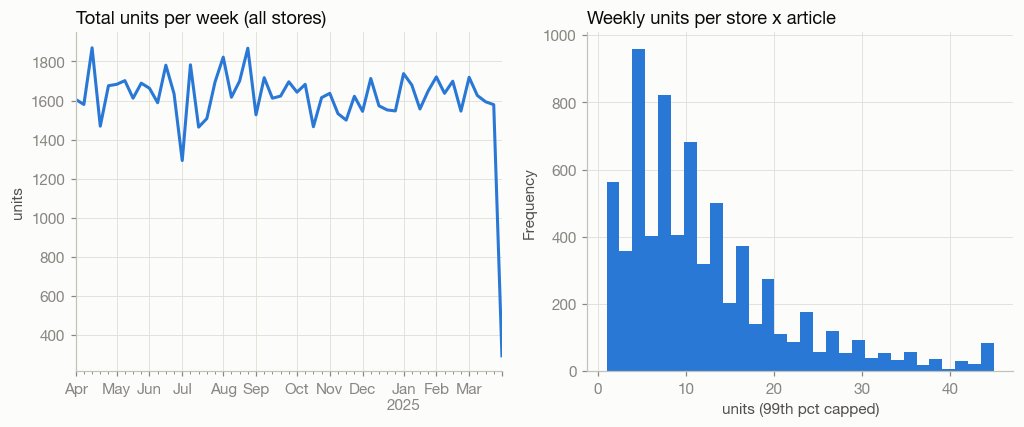

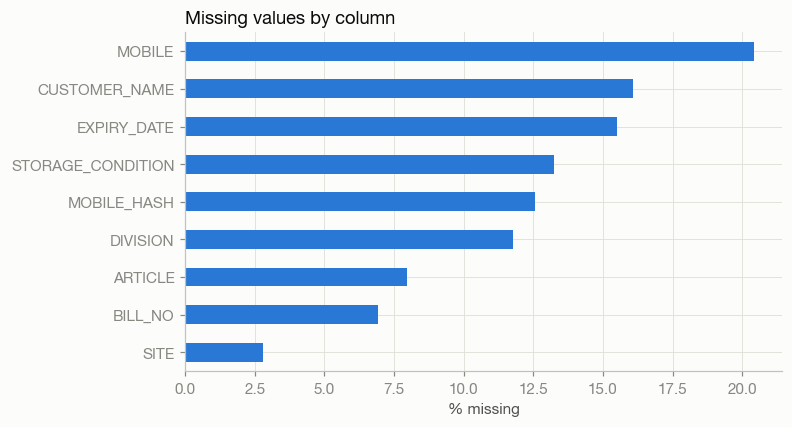

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tot.plot(ax=ax[0], color=SERIES[0]); ax[0].set_title("Total units per week (all stores)"); ax[0].set_ylabel("units"); ax[0].set_xlabel("")
w.weekly_units.clip(upper=w.weekly_units.quantile(.99)).plot.hist(bins=30, ax=ax[1], color=SERIES[0]); ax[1].set_title("Weekly units per store x article"); ax[1].set_xlabel("units (99th pct capped)")
save(fig, "03_target")
miss = (d.isna().mean() * 100).sort_values(ascending=False); miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(7, 4)); miss.iloc[::-1].plot.barh(ax=ax, color=SERIES[0]); ax.set_xlabel("% missing"); ax.set_title("Missing values by column")
save(fig, "03_missing")

In [8]:
try:
    from ydata_profiling import ProfileReport
    ProfileReport(d, minimal=True, title="perishable_45k profile").to_file("reports/03_profile.html")
    print("profile html written")
except Exception as e:
    print("ydata-profiling skipped:", type(e).__name__, e)

/Users/parthasen/Downloads/DSLC/envs/dslc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/_s/s7hnymmn39d5ptgj1rb5wvy40000gn/T/ipykernel_34915/2463806286.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/46 [00:00<?, ?it/s, Describe variable: SITE]

Summarize dataset:   0%|          | 0/46 [00:00<?, ?it/s, Describe variable: SITE_NAME]

...

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  2.57it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 60.00it/s]

profile html written
